In [23]:
#imports
from f1strategy.data import setup_cache, get_data, get_session, filter_data
import matplotlib.pyplot as plt

In [2]:
#Setup fastF1 cache so we are not redownloading data
setup_cache()

In [25]:
session, event = get_session(2025, "Bahrain Grand Prix")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

In [26]:
data = get_data(session, event)

data.head(40)

,Driver,LapNumber,LapTime,TyreLife,Compound,Stint,TrackStatus,PitInTime,PitOutTime,IsAccurate,Country,RoundNumber,EventName
0,PIA,1.0,98.693,4.0,SOFT,1.0,1,NaN,NaN,False,Bahrain,4,Bahrain Grand Prix
1,PIA,2.0,97.492,5.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
2,PIA,3.0,98.083,6.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
3,PIA,4.0,98.133,7.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
4,PIA,5.0,98.043,8.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
5,PIA,6.0,98.363,9.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
6,PIA,7.0,98.498,10.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
7,PIA,8.0,98.567,11.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
8,PIA,9.0,98.800,12.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
9,PIA,10.0,98.549,13.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix


In [27]:
filtered = filter_data(data)

filtered.head(40)

,Driver,LapNumber,LapTime,TyreLife,Compound,Stint,TrackStatus,PitInTime,PitOutTime,IsAccurate,Country,RoundNumber,EventName
1,PIA,2.0,97.492,5.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
2,PIA,3.0,98.083,6.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
3,PIA,4.0,98.133,7.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
4,PIA,5.0,98.043,8.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
5,PIA,6.0,98.363,9.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
6,PIA,7.0,98.498,10.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
7,PIA,8.0,98.567,11.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
8,PIA,9.0,98.800,12.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
9,PIA,10.0,98.549,13.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
10,PIA,11.0,98.681,14.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix


In [44]:
example = filtered[(filtered["Driver"] == "VER") & (filtered["Stint"] == 1)].sort_values("TyreLife")
example

,Driver,LapNumber,LapTime,TyreLife,Compound,Stint,TrackStatus,PitInTime,PitOutTime,IsAccurate,Country,RoundNumber,EventName
286,VER,2.0,98.403,5.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
287,VER,3.0,98.475,6.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
288,VER,4.0,98.549,7.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
289,VER,5.0,98.760,8.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
290,VER,6.0,98.593,9.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
291,VER,7.0,98.929,10.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
292,VER,8.0,99.385,11.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix
293,VER,9.0,99.670,12.0,SOFT,1.0,1,NaN,NaN,True,Bahrain,4,Bahrain Grand Prix


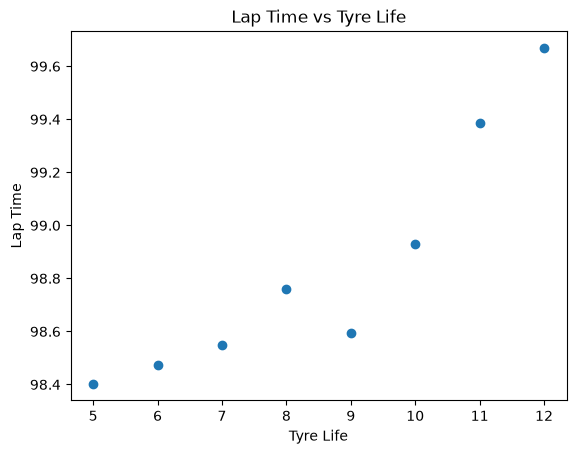

In [45]:
#Plot lap time vs tyre life
plt.scatter(example['TyreLife'], example['LapTime'])
plt.xlabel('Tyre Life')
plt.ylabel('Lap Time')
plt.title('Lap Time vs Tyre Life')
plt.show()

#Looks almost exponential, need a non linear model for deg